In [5]:
import os, yaml, sys
import numpy as np
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
import cv2

ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])


height: 999 
width: 1500


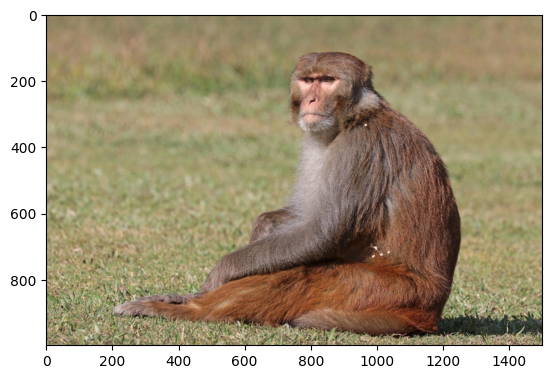

In [6]:
img_path = f"{paths['data_path']}/possible_vids/starting_imgs/macaque01.jpg"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w, c = img.shape
print(f"height: {h} \nwidth: {w}")
plt.imshow(img)

In [13]:
h_stride, w_stride = 30, 10
h_win, w_win = 200, 200
h_st, w_st = 600, 800


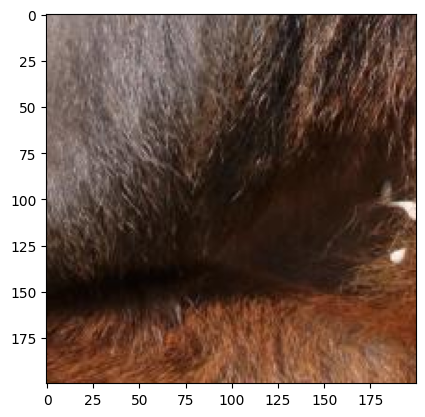

In [16]:
for i in np.arange(h_st, h - h_win -1, h_stride)[::-1]:
    plt.imshow(img[i:i+h_win,w_st:w_st+w_win,:])
    plt.show()
    clear_output(wait=True)


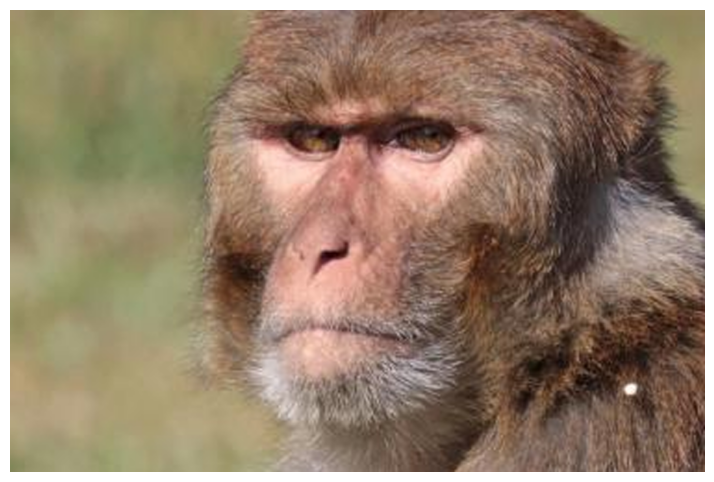

In [18]:
duration_s = 2.5
fps = 50
n_frames = int(duration_s * fps)

# Approximate target for macaque01.jpg: center the final camera view on the face.
start_center = np.array([w / 2, h / 2], dtype=float)
end_center = np.array([820, 255], dtype=float)
start_crop_h = h
end_crop_h = 250
output_w = 900
output_h = int(output_w * h / w)
frame_dt = 1 / fps

for frame_idx in range(n_frames):
    tic = time.time()
    t = frame_idx / (n_frames - 1)
    t = t * t * (3 - 2 * t)

    crop_h = (1 - t) * start_crop_h + t * end_crop_h
    crop_w = crop_h * w / h
    center = (1 - t) * start_center + t * end_center

    x0 = int(np.clip(center[0] - crop_w / 2, 0, w - crop_w))
    y0 = int(np.clip(center[1] - crop_h / 2, 0, h - crop_h))
    x1 = int(x0 + crop_w)
    y1 = int(y0 + crop_h)

    frame = img[y0:y1, x0:x1, :]
    frame = cv2.resize(frame, (output_w, output_h), interpolation=cv2.INTER_CUBIC)

    plt.figure(figsize=(9, 6))
    plt.imshow(frame)
    plt.axis("off")
    plt.show()
    clear_output(wait=True)
    time.sleep(max(0, frame_dt - (time.time() - tic)))


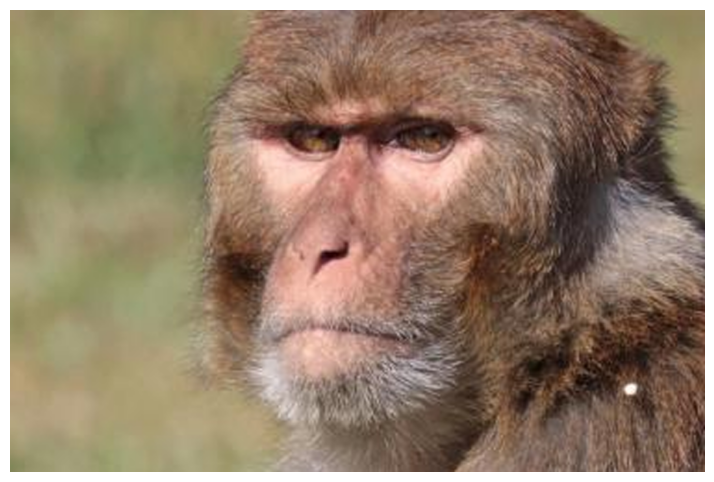

In [21]:
duration_s = 2.5
fps = 50
n_frames = int(duration_s * fps)

# Fixed-zoom camera path: translate across the image and finish on the face.
fixed_crop_h = 250
fixed_crop_w = fixed_crop_h * w / h
start_center = np.array([520, 820], dtype=float)
end_center = np.array([820, 255], dtype=float)
output_w = 900
output_h = int(output_w * h / w)
frame_dt = 1 / fps

path = end_center - start_center
path_norm = np.linalg.norm(path)
path_perp = np.array([-path[1], path[0]]) / path_norm
drift_px = 35

for frame_idx in range(n_frames):
    tic = time.time()
    t = frame_idx / (n_frames - 1)
    t_smooth = t * t * (3 - 2 * t)

    center = (1 - t_smooth) * start_center + t_smooth * end_center
    center = center + drift_px * np.sin(np.pi * t_smooth) * path_perp

    x0 = int(np.clip(center[0] - fixed_crop_w / 2, 0, w - fixed_crop_w))
    y0 = int(np.clip(center[1] - fixed_crop_h / 2, 0, h - fixed_crop_h))
    x1 = int(x0 + fixed_crop_w)
    y1 = int(y0 + fixed_crop_h)

    frame = img[y0:y1, x0:x1, :]
    frame = cv2.resize(frame, (output_w, output_h), interpolation=cv2.INTER_CUBIC)

    plt.figure(figsize=(9, 6))
    plt.imshow(frame)
    plt.axis("off")
    plt.show()
    clear_output(wait=True)
    time.sleep(max(0, frame_dt - (time.time() - tic)))


frames: 250
fps: 50.0
height: 400
width: 376


(np.float64(-0.5), np.float64(375.5), np.float64(399.5), np.float64(-0.5))

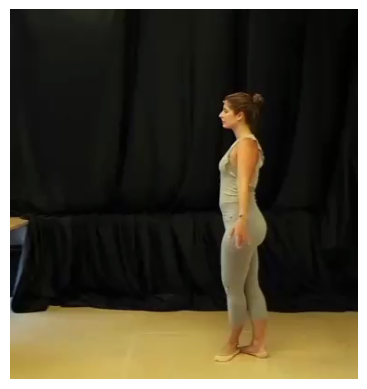

In [22]:
ballet_video_path = "/Users/tizianocausin/Desktop/ballet_stim.mp4"
cap = cv2.VideoCapture(ballet_video_path)
ballet_fps = cap.get(cv2.CAP_PROP_FPS)
ballet_frames = []

while True:
    ok, frame = cap.read()
    if not ok:
        break
    ballet_frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

cap.release()
ballet_frames = np.stack(ballet_frames)
n_ballet_frames, ballet_h, ballet_w, _ = ballet_frames.shape
print(f"frames: {n_ballet_frames}\nfps: {ballet_fps}\nheight: {ballet_h}\nwidth: {ballet_w}")
plt.imshow(ballet_frames[0])
plt.axis("off")


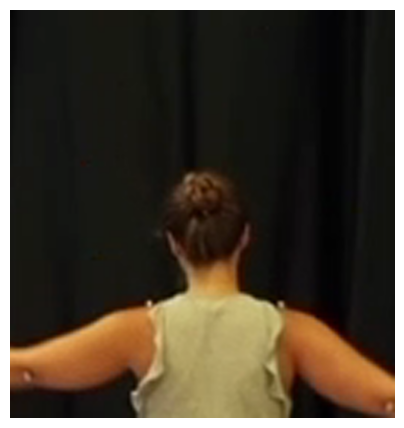

In [23]:
# Camera path over the real video frames: zoom in and finish on the dancer's head.
head_center = np.array([202, 112], dtype=float)
start_center = np.array([ballet_w / 2, ballet_h / 2], dtype=float)
start_crop_h = ballet_h
end_crop_h = 140
output_w = 500
output_h = int(output_w * ballet_h / ballet_w)
frame_dt = 1 / ballet_fps

for frame_idx, src_frame in enumerate(ballet_frames):
    tic = time.time()
    t = frame_idx / (n_ballet_frames - 1)
    t = t * t * (3 - 2 * t)

    crop_h = (1 - t) * start_crop_h + t * end_crop_h
    crop_w = crop_h * ballet_w / ballet_h
    center = (1 - t) * start_center + t * head_center

    x0 = int(np.clip(center[0] - crop_w / 2, 0, ballet_w - crop_w))
    y0 = int(np.clip(center[1] - crop_h / 2, 0, ballet_h - crop_h))
    x1 = int(x0 + crop_w)
    y1 = int(y0 + crop_h)

    frame = src_frame[y0:y1, x0:x1, :]
    frame = cv2.resize(frame, (output_w, output_h), interpolation=cv2.INTER_CUBIC)

    plt.figure(figsize=(5, 5.3))
    plt.imshow(frame)
    plt.axis("off")
    plt.show()
    clear_output(wait=True)
    time.sleep(max(0, frame_dt - (time.time() - tic)))


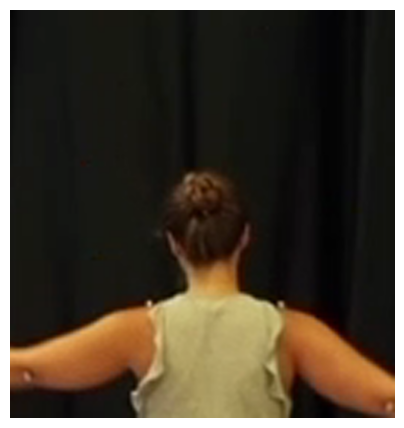

In [24]:
# Fixed-zoom camera path over the real video frames: translate and finish on the head.
head_center = np.array([202, 112], dtype=float)
fixed_crop_h = 140
fixed_crop_w = fixed_crop_h * ballet_w / ballet_h
start_center = np.array([110, 320], dtype=float)
output_w = 500
output_h = int(output_w * ballet_h / ballet_w)
frame_dt = 1 / ballet_fps

path = head_center - start_center
path_norm = np.linalg.norm(path)
path_perp = np.array([-path[1], path[0]]) / path_norm
drift_px = 18

for frame_idx, src_frame in enumerate(ballet_frames):
    tic = time.time()
    t = frame_idx / (n_ballet_frames - 1)
    t_smooth = t * t * (3 - 2 * t)

    center = (1 - t_smooth) * start_center + t_smooth * head_center
    center = center + drift_px * np.sin(np.pi * t_smooth) * path_perp

    x0 = int(np.clip(center[0] - fixed_crop_w / 2, 0, ballet_w - fixed_crop_w))
    y0 = int(np.clip(center[1] - fixed_crop_h / 2, 0, ballet_h - fixed_crop_h))
    x1 = int(x0 + fixed_crop_w)
    y1 = int(y0 + fixed_crop_h)

    frame = src_frame[y0:y1, x0:x1, :]
    frame = cv2.resize(frame, (output_w, output_h), interpolation=cv2.INTER_CUBIC)

    plt.figure(figsize=(5, 5.3))
    plt.imshow(frame)
    plt.axis("off")
    plt.show()
    clear_output(wait=True)
    time.sleep(max(0, frame_dt - (time.time() - tic)))
